In [1]:
#========================================================================
# Name: filter_wrf_dsd_properties_congestus.ipynb
# Author: McKenna W. Stanford
# Author Contact: mckenna.stanford@pnnl.gov
# Date Created: 05/22/2025
#
# Utility: Reads in CTH variables from derived files and pulls in the
# corresponding derived gamma dsd properties. Then limits the simulated
# dataset to the ridgeline, CTTs at least shallow enough to be considered
# congestus (i.e., > -25 deg C), and limits points in general to be above 0
# deg C.
#========================================================================

In [1]:
#===============================
# Imports
#===============================
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob 
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import datetime
import matplotlib.colors as colors
import matplotlib as mpl
from pytz import utc
from matplotlib.lines import Line2D
import pickle
from scipy.spatial import cKDTree
import pandas as pd

import dask
from distributed import Client, LocalCluster
from dask import delayed, compute
import dask.array as da

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.img_tiles as cimgt
import shapely.geometry as sgeom
import matplotlib.patheffects as path_effects

import scipy
import warnings
warnings.filterwarnings("ignore")
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

plt.rcParams['text.usetex'] = True

/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


# 500-m Native

In [2]:
with open('LASSO_500m_native_dsd_props_cu_only.p', 'rb') as f:
    d3_native_wrf_dict = pickle.load(f)
d3_native_wrf_dict['N'] = d3_native_wrf_dict['N']*d3_native_wrf_dict['rho_air']*1.e-6

In [3]:
filter_qc_bool = True
qc_thresh = 1.e-6
qc_id = np.where(d3_native_wrf_dict['qc']*d3_native_wrf_dict['rho_air']*1.e3 > qc_thresh)[0]
no_qc_id = np.where(d3_native_wrf_dict['qc']*d3_native_wrf_dict['rho_air']*1.e3 <= qc_thresh)[0]
print(len(qc_id)/len(d3_native_wrf_dict['q'])*100.)
print(len(no_qc_id)/len(d3_native_wrf_dict['q'])*100.)
if filter_qc_bool:
    for key,val in d3_native_wrf_dict.items():
        d3_native_wrf_dict[key] = val[qc_id]

32.54472245545109
67.4552775445489


In [4]:
wa = d3_native_wrf_dict['wa']
dumid = np.where(wa > 1.)[0]
d3_native_wrf_dict_updraft = d3_native_wrf_dict.copy()

for key,val in d3_native_wrf_dict_updraft.items():
    d3_native_wrf_dict_updraft[key] = val[dumid]

# 500-m Coarse-grained

In [5]:
with open('LASSO_d3_dsd_props_cu_only.p', 'rb') as f:
    d3_wrf_dict = pickle.load(f)
d3_wrf_dict['N'] = d3_wrf_dict['N']*d3_wrf_dict['rho_air']*1.e-6

In [6]:
filter_qc_bool = True
qc_thresh = 1.e-6
qc_id = np.where(d3_wrf_dict['qc']*d3_wrf_dict['rho_air']*1.e3 > qc_thresh)[0]
no_qc_id = np.where(d3_wrf_dict['qc']*d3_wrf_dict['rho_air']*1.e3 <= qc_thresh)[0]
print(len(qc_id)/len(d3_wrf_dict['q'])*100.)
print(len(no_qc_id)/len(d3_wrf_dict['q'])*100.)
if filter_qc_bool:
    for key,val in d3_wrf_dict.items():
        d3_wrf_dict[key] = val[qc_id]

54.26662642540627
45.73337357459373


In [7]:
wa = d3_wrf_dict['wa']
dumid = np.where(wa > 1.)[0]
d3_wrf_dict_updraft = d3_wrf_dict.copy()

for key,val in d3_wrf_dict_updraft.items():
    d3_wrf_dict_updraft[key] = val[dumid]

# Read in and process observational dataset

In [8]:
with open('/global/homes/m/mckenna/projdir/cacti/aircraft_in_situ/post/processed_merged_flight_dictionaries.p', 'rb') as f:
    in_obs_dict = pickle.load(f)

In [9]:
print(np.shape(in_obs_dict['20181106']['diameter_bounds']))
dD = in_obs_dict['20181106']['diameter_bounds'][:,1] - in_obs_dict['20181106']['diameter_bounds'][:,0]
dlogD = np.log10(in_obs_dict['20181106']['diameter_bounds'][:,1]) - np.log10(in_obs_dict['20181106']['diameter_bounds'][:,0])

(86, 2)


In [10]:
in_obs_dict['20181104'].keys()

dict_keys(['time_dt', 'altitude', 'ambient_temp', 'rh', 'rh2', 'vertical_velocity', 'vertical_wind_speed', 'diameter_centers', 'diameter_bounds', 'dNdD', 'integrated_lwc', 'integrated_total_conc', 'LWC_gt_100um', 'Nd_gt_100um', 'D_vol', 'D_num', 'D_mass', 'mmd', 'dMdD', 'fcdp_lwc', 'wcm_twc'])

In [11]:
all_total_conc = []
all_total_lwc = []
all_conc_gt_100um = []
all_lwc_gt_100um = []
all_temp = []
all_mmd = []
all_D_num = []
all_D_vol = []
all_D_mass = []
all_w = []
all_dN = []
all_dM = []
all_temp = []
all_rh = []
all_time = []
all_alt = []
all_fcdp_lwc = []

dumi=0
for key in in_obs_dict.keys():
#for key in merged_dict.keys():

    if dumi==0:
        obs_diam = in_obs_dict[key]['diameter_centers']
        obs_dD = in_obs_dict[key]['diameter_bounds'][:,1] - in_obs_dict[key]['diameter_bounds'][:,0]
        obs_dlogD = np.log10(in_obs_dict[key]['diameter_bounds'][:,1]) - np.log10(in_obs_dict[key]['diameter_bounds'][:,0])

    if True:
        tmp_total_conc = in_obs_dict[key]['integrated_total_conc'].copy() # /cm^3
        tmp_total_lwc = in_obs_dict[key]['integrated_lwc'].copy() # g/m^3
        tmp_conc_gt_100um = in_obs_dict[key]['Nd_gt_100um'].copy() # /cm^-3
        tmp_lwc_gt_100um = in_obs_dict[key]['LWC_gt_100um'].copy() # g/m^3
        tmp_temp = in_obs_dict[key]['ambient_temp'].copy() # deg C
        tmp_rh = in_obs_dict[key]['rh'].copy() # %
        tmp_w = in_obs_dict[key]['vertical_wind_speed'].copy() # m/s
        tmp_mmd = in_obs_dict[key]['mmd'].copy() # um
        tmp_D_num = in_obs_dict[key]['D_num'].copy() # um
        tmp_D_vol = in_obs_dict[key]['D_vol'].copy() # um
        tmp_D_mass = in_obs_dict[key]['D_mass'].copy() # um
        tmp_dN = in_obs_dict[key]['dNdD'].copy() # /cm^3/um
        tmp_dM = in_obs_dict[key]['dMdD'].copy() # g/m^3/um
        tmp_time = in_obs_dict[key]['time_dt'].copy() 
        tmp_alt = in_obs_dict[key]['altitude'].copy() 
        tmp_fcdp_lwc = in_obs_dict[key]['fcdp_lwc'].copy() 
    
    lwc_thresh = 1.e-3
    conc_thresh = 0
    dumid = np.where( (tmp_total_conc > conc_thresh) & (tmp_total_lwc > lwc_thresh) & (tmp_temp > 0.) )
    #dumid = np.where( (tmp_total_conc > conc_thresh) & (tmp_total_lwc > lwc_thresh) & (tmp_temp > 0.) & (tmp_rh >= 100.) )
    dumid = dumid[0]
    tmp_total_conc = tmp_total_conc[dumid]
    tmp_total_lwc = tmp_total_lwc[dumid]
    tmp_conc_gt_100um = tmp_conc_gt_100um[dumid]
    tmp_lwc_gt_100um = tmp_lwc_gt_100um[dumid]
    tmp_temp = tmp_temp[dumid]
    tmp_rh = tmp_rh[dumid]
    tmp_w = tmp_w[dumid]
    tmp_mmd = tmp_mmd[dumid]
    tmp_D_num = tmp_D_num[dumid]
    tmp_D_vol = tmp_D_vol[dumid]
    tmp_D_mass = tmp_D_mass[dumid]
    tmp_dN = tmp_dN[dumid,:]
    tmp_dM = tmp_dM[dumid,:]
    tmp_alt = tmp_alt[dumid]
    tmp_time = tmp_time[dumid]
    tmp_fcdp_lwc = tmp_fcdp_lwc[dumid]
    
    all_total_conc.append(tmp_total_conc)
    all_total_lwc.append(tmp_total_lwc)
    all_conc_gt_100um.append(tmp_conc_gt_100um)
    all_lwc_gt_100um.append(tmp_lwc_gt_100um)
    all_temp.append(tmp_temp)
    all_rh.append(tmp_rh)
    all_w.append(tmp_w)
    all_mmd.append(tmp_mmd)
    all_D_num.append(tmp_D_num)
    all_D_vol.append(tmp_D_vol)
    all_D_mass.append(tmp_D_mass)
    all_dN.append(tmp_dN)
    all_dM.append(tmp_dM)
    all_alt.append(tmp_alt)
    all_time.append(tmp_time)
    all_fcdp_lwc.append(tmp_fcdp_lwc)

    dumi+=1

all_total_conc = np.concatenate(all_total_conc)
all_total_lwc = np.concatenate(all_total_lwc)
all_conc_gt_100um = np.concatenate(all_conc_gt_100um)
all_lwc_gt_100um = np.concatenate(all_lwc_gt_100um)
all_temp = np.concatenate(all_temp)
all_rh = np.concatenate(all_rh)
all_w = np.concatenate(all_w)
all_mmd = np.concatenate(all_mmd)
all_D_num = np.concatenate(all_D_num)
all_D_vol = np.concatenate(all_D_vol)
all_D_mass = np.concatenate(all_D_mass)
all_dN = np.concatenate(all_dN)
all_dM = np.concatenate(all_dM)
all_alt = np.concatenate(all_alt)
all_time = np.concatenate(all_time)
all_fcdp_lwc = np.concatenate(all_fcdp_lwc)

obs_dict = {'total_conc':all_total_conc,\
            'cloud_lwc':all_total_lwc,\
            'conc_gt_100um':all_conc_gt_100um,\
            'lwc_gt_100um':all_lwc_gt_100um,\
            'w':all_w,\
            'mmd':all_mmd,\
            'D_num':all_D_num,\
            'D_vol':all_D_vol,\
            'D_mass':all_D_mass,\
            'dNdD':all_dN,\
            'dMdD':all_dM,\
            'time':all_time,\
            'alt':all_alt,\
            'temp':all_temp,\
            'rh':all_rh,\
            'fcdp_lwc':all_fcdp_lwc,\
           }

In [12]:
for key, val in obs_dict.items():
    print(key,np.shape(val),np.nanmin(val),np.nanmax(val))

total_conc (17293,) 9.314999438458926e-07 1207.6459032371204
cloud_lwc (17293,) 0.0010000253970844735 6.430327544374225
conc_gt_100um (17293,) 0.0 0.3358029403099039
lwc_gt_100um (17293,) 0.0 6.126754471883832
w (17293,) -7.46 10.4
mmd (17293,) 5.182806145379091 8301.833132185773
D_num (17293,) 2.277037644625985 3930.168636824342
D_vol (17293,) 5.1703650761027315 8195.346824579328
D_mass (17293,) 5.17036526364409 8195.34650657086
dNdD (17293, 86) 0.0 216.96800231933594
dMdD (17293, 86) 0.0 0.4096303357240658
time (17293,) 2018-11-04 13:27:48+00:00 2018-12-07 18:53:42+00:00
alt (17293,) 530.0 4737.0
temp (17293,) 0.1 28.9
rh (17293,) 4.0 155.0
fcdp_lwc (17293,) 0.0 3.452444574469217


In [13]:
min_fcdp_lwc_thresh = 1.e-6
obs_fcdp_lwc_cloud_id = np.where(obs_dict['fcdp_lwc'] > min_fcdp_lwc_thresh)[0]
obs_fcdp_lwc_non_cloud_id = np.where(obs_dict['fcdp_lwc'] <= min_fcdp_lwc_thresh)[0]
print(len(obs_fcdp_lwc_cloud_id)/len(obs_dict['fcdp_lwc'])*100.)
print(len(obs_fcdp_lwc_non_cloud_id)/len(obs_dict['fcdp_lwc'])*100.)
filter_fcdp_lwc_bool = True
if filter_fcdp_lwc_bool:
    for key,val in obs_dict.items():
        obs_dict[key] = val[obs_fcdp_lwc_cloud_id]

97.21274504134621
2.7872549586537905


In [14]:
obs_dict_updraft = obs_dict.copy()
dumid = np.where(obs_dict_updraft['w'] > 1.)[0]
for key,val in obs_dict_updraft.items():
    obs_dict_updraft[key] = val[dumid]

for key, val in obs_dict_updraft.items():
    print(key,np.shape(val),np.nanmin(val),np.nanmax(val))

total_conc (2231,) 0.06493428552494152 1207.6459032371204
cloud_lwc (2231,) 0.0010176837346208478 3.3326037964881943
conc_gt_100um (2231,) 0.0 0.1630999892950058
lwc_gt_100um (2231,) 0.0 1.838029432109243
w (2231,) 1.01 10.4
mmd (2231,) 7.125 8301.833132185773
D_num (2231,) 3.4272690559679666 36.72643653616218
D_vol (2231,) 7.000000307517347 8195.346824579328
D_mass (2231,) 6.999999999999999 8195.34650657086
dNdD (2231, 86) 0.0 209.3800048828125
dMdD (2231, 86) 0.0 0.4096303357240658
time (2231,) 2018-11-04 14:32:47+00:00 2018-12-07 18:52:55+00:00
alt (2231,) 910.0 4737.0
temp (2231,) 0.1 24.3
rh (2231,) 7.0 155.0
fcdp_lwc (2231,) 1.7852879880514908e-06 2.955129656558261


In [15]:
def calc_hist2d(xvar,yvar,xbins,ybins):
    xmidbins = np.array([0.5*(xbins[dd]+xbins[dd+1]) for dd in range(len(xbins)-1)])
    ymidbins = np.array([0.5*(ybins[dd]+ybins[dd+1]) for dd in range(len(ybins)-1)])

    num_xbins = len(xbins)
    num_ybins = len(ybins)
    total_samp_size = len(xvar)
    xdiff = np.diff(xbins)
    ydiff = np.diff(ybins)

    hist = np.zeros((num_xbins-1,num_ybins-1))
    frac = np.zeros((num_xbins-1,num_ybins-1))
    pdf = np.zeros((num_xbins-1,num_ybins-1))

    thresh = 0
    for ii in range(num_xbins-1):
        for jj in range(num_ybins-1):
            dumid = np.where( (xvar >= xbins[ii]) & (xvar < xbins[ii+1]) & (yvar >= ybins[jj]) & (yvar < ybins[jj+1]) )
            if np.size(dumid) > thresh:
                dumid = dumid[0]
                bin_samp_size = np.size(dumid)
                hist[ii,jj] = bin_samp_size
                frac[ii,jj] = bin_samp_size/total_samp_size
                pdf[ii,jj] = bin_samp_size/total_samp_size/xdiff[ii]/ydiff[jj]
            else:
                hist[ii,jj] = 0.
                frac[ii,jj] = 0.
                pdf[ii,jj] = 0.

    return hist,frac,pdf

In [16]:
def calc_hist2d_filled(xvar,yvar,zvar,xbins,ybins):
    xmidbins = np.array([0.5*(xbins[dd]+xbins[dd+1]) for dd in range(len(xbins)-1)])
    ymidbins = np.array([0.5*(ybins[dd]+ybins[dd+1]) for dd in range(len(ybins)-1)])
    
    num_xbins = len(xbins)
    num_ybins = len(ybins)
    total_samp_size = len(xvar)
    xdiff = np.diff(xbins)
    ydiff = np.diff(ybins)
    
    mean = np.zeros((num_xbins-1,num_ybins-1))
    stddev = np.zeros((num_xbins-1,num_ybins-1))
    med = np.zeros((num_xbins-1,num_ybins-1))

    thresh = 0
    for ii in range(num_xbins-1):
        for jj in range(num_ybins-1):
            dumid = np.where( (xvar >= xbins[ii]) & (xvar < xbins[ii+1]) & (yvar >= ybins[jj]) & (yvar < ybins[jj+1])  )
            if np.size(dumid) > thresh:
                dumid = dumid[0]
                zvar_lim = zvar[dumid]
                mean[ii,jj] = np.nanmean(zvar_lim)
                #print(mean[ii,jj])
                stddev[ii,jj] = np.nanstd(zvar_lim)
                med[ii,jj] = np.nanmedian(zvar_lim)
            else:
                mean[ii,jj] = 0.
                med[ii,jj] = 0.
                stddev[ii,jj] = 0.
    
    return mean,med,stddev

In [17]:
def calc_hist2d_filled_special(xvar,yvar,zvar,xbins,ybins):
    xmidbins = np.array([0.5*(xbins[dd]+xbins[dd+1]) for dd in range(len(xbins)-1)])
    ymidbins = np.array([0.5*(ybins[dd]+ybins[dd+1]) for dd in range(len(ybins)-1)])
    
    num_xbins = len(xbins)
    num_ybins = len(ybins)
    total_samp_size = len(xvar)
    xdiff = np.diff(xbins)
    ydiff = np.diff(ybins)
    
    mean = np.zeros((num_xbins-1,num_ybins-1))
    stddev = np.zeros((num_xbins-1,num_ybins-1))
    med = np.zeros((num_xbins-1,num_ybins-1))

    thresh = 0
    for ii in range(num_xbins-1):
        for jj in range(num_ybins-1):
            dumid = np.where( (xvar >= xbins[ii]) & (xvar < xbins[ii+1]) & (yvar >= ybins[jj]) & (yvar < ybins[jj+1])  )
            if np.size(dumid) > thresh:
                dumid = dumid[0]
                zvar_lim = zvar[dumid]
                mean[ii,jj] = np.nanmean(zvar_lim)
                #print(mean[ii,jj])
                stddev[ii,jj] = np.nanstd(zvar_lim)
                med[ii,jj] = np.nanmedian(zvar_lim)
            else:
                mean[ii,jj] = -999.
                med[ii,jj] = -999.
                stddev[ii,jj] = -999.
    
    return mean,med,stddev

# Fraction of total mass in sizes > 100 um - Linear Colorscale

In [18]:
tot_mass = obs_dict['cloud_lwc'].copy()
lim_mass = obs_dict['lwc_gt_100um'].copy()
tmp_var = lim_mass/tot_mass

tot_mass_updraft = obs_dict_updraft['cloud_lwc'].copy()
lim_mass_updraft = obs_dict_updraft['lwc_gt_100um'].copy()
tmp_var_updraft = lim_mass_updraft/tot_mass_updraft


# Obs
lwc_bins = 10.**np.arange(-3.,1.5,0.25) # g/m^3
lwc_midbins = np.array([0.5*(lwc_bins[dd]+lwc_bins[dd+1]) for dd in range(len(lwc_bins)-1)])

conc_bins_lin = np.arange(0,1050,50) # /cm^3
conc_midbins_lin = np.array([0.5*(conc_bins_lin[dd]+conc_bins_lin[dd+1]) for dd in range(len(conc_bins_lin)-1)])

obs_hist_linlog,obs_frac_linlog,obs_pdf_linlog = calc_hist2d(obs_dict['cloud_lwc'],obs_dict['total_conc'],lwc_bins,conc_bins_lin)
obs_mean_linlog,obs_med_linlog,obs_stddev_linlog = calc_hist2d_filled_special(obs_dict['cloud_lwc'],obs_dict['total_conc'],tmp_var,lwc_bins,conc_bins_lin)

obs_hist_linlog_updraft,obs_frac_linlog_updraft,obs_pdf_linlog_updraft = calc_hist2d(obs_dict_updraft['cloud_lwc'],obs_dict_updraft['total_conc'],lwc_bins,conc_bins_lin)
obs_mean_linlog_updraft,obs_med_linlog_updraft,obs_stddev_linlog_updraft = calc_hist2d_filled_special(obs_dict_updraft['cloud_lwc'],obs_dict_updraft['total_conc'],tmp_var_updraft,lwc_bins,conc_bins_lin)

conc_bins_log = 10.**np.arange(0,3.5,0.25)# /cm^3
conc_midbins_log = np.array([0.5*(conc_bins_log[dd]+conc_bins_log[dd+1]) for dd in range(len(conc_bins_log)-1)])

obs_hist_loglog,obs_frac_loglog,obs_pdf_loglog = calc_hist2d(obs_dict['cloud_lwc'],obs_dict['total_conc'],lwc_bins,conc_bins_log)
obs_mean_loglog,obs_med_loglog,obs_stddev_loglog = calc_hist2d_filled_special(obs_dict['cloud_lwc'],obs_dict['total_conc'],tmp_var,lwc_bins,conc_bins_log)

obs_hist_loglog_updraft,obs_frac_loglog_updraft,obs_pdf_loglog_updraft = calc_hist2d(obs_dict_updraft['cloud_lwc'],obs_dict_updraft['total_conc'],lwc_bins,conc_bins_log)
obs_mean_loglog_updraft,obs_med_loglog_updraft,obs_stddev_loglog_updraft = calc_hist2d_filled_special(obs_dict_updraft['cloud_lwc'],obs_dict_updraft['total_conc'],tmp_var_updraft,lwc_bins,conc_bins_log)

obs_mean_linlog[obs_mean_linlog == -999.] = np.nan
obs_mean_loglog[obs_mean_loglog == -999.] = np.nan

obs_mean_linlog_updraft[obs_mean_linlog_updraft == -999.] = np.nan
obs_mean_loglog_updraft[obs_mean_loglog_updraft == -999.] = np.nan

In [19]:
#======================================
# WRF d3
#======================================
tot_mass = d3_wrf_dict['lwc'].copy()
lim_mass = d3_wrf_dict['q_gt_100um'].copy()*d3_wrf_dict['rho_air'].copy()*1.e3
tmp_var = lim_mass/tot_mass
print(np.max(tmp_var))

# WRF
d3_wrf_hist_linlog,d3_wrf_frac_linlog,d3_wrf_pdf_linlog = calc_hist2d(d3_wrf_dict['lwc'],d3_wrf_dict['N'],lwc_bins,conc_bins_lin)
d3_wrf_mean_linlog,d3_wrf_med_linlog,d3_wrf_stddev_linlog = calc_hist2d_filled_special(d3_wrf_dict['lwc'],d3_wrf_dict['N'],tmp_var,lwc_bins,conc_bins_lin)

d3_wrf_hist_loglog,d3_wrf_frac_loglog,d3_wrf_pdf_loglog = calc_hist2d(d3_wrf_dict['lwc'],d3_wrf_dict['N'],lwc_bins,conc_bins_log)
d3_wrf_mean_loglog,d3_wrf_med_loglog,d3_wrf_stddev_loglog = calc_hist2d_filled_special(d3_wrf_dict['lwc'],d3_wrf_dict['N'],tmp_var,lwc_bins,conc_bins_log)

d3_wrf_mean_linlog[d3_wrf_mean_linlog == -999.] = np.nan
d3_wrf_mean_loglog[d3_wrf_mean_loglog == -999.] = np.nan

0.9999380569910107


In [20]:
#======================================
# WRF d3 updraft
#======================================
tot_mass_updraft = d3_wrf_dict_updraft['lwc'].copy()
lim_mass_updraft = d3_wrf_dict_updraft['q_gt_100um'].copy()*d3_wrf_dict_updraft['rho_air'].copy()*1.e3
tmp_var_updraft = lim_mass_updraft/tot_mass_updraft
print(np.max(tmp_var_updraft))

# WRF
d3_wrf_hist_linlog_updraft,d3_wrf_frac_linlog_updraft,d3_wrf_pdf_linlog_updraft = calc_hist2d(d3_wrf_dict_updraft['lwc'],d3_wrf_dict_updraft['N'],lwc_bins,conc_bins_lin)
d3_wrf_mean_linlog_updraft,d3_wrf_med_linlog_updraft,d3_wrf_stddev_linlog_updraft = calc_hist2d_filled_special(d3_wrf_dict_updraft['lwc'],d3_wrf_dict_updraft['N'],tmp_var_updraft,lwc_bins,conc_bins_lin)

d3_wrf_hist_loglog_updraft,d3_wrf_frac_loglog_updraft,d3_wrf_pdf_loglog_updraft = calc_hist2d(d3_wrf_dict_updraft['lwc'],d3_wrf_dict_updraft['N'],lwc_bins,conc_bins_log)
d3_wrf_mean_loglog_updraft,d3_wrf_med_loglog_updraft,d3_wrf_stddev_loglog_updraft = calc_hist2d_filled_special(d3_wrf_dict_updraft['lwc'],d3_wrf_dict_updraft['N'],tmp_var_updraft,lwc_bins,conc_bins_log)

d3_wrf_mean_linlog_updraft[d3_wrf_mean_linlog_updraft == -999.] = np.nan
d3_wrf_mean_loglog_updraft[d3_wrf_mean_loglog_updraft == -999.] = np.nan

0.9999088909930194


In [21]:
#======================================
# WRF d3 native
#======================================
tot_mass = d3_native_wrf_dict['lwc'].copy()
lim_mass = d3_native_wrf_dict['q_gt_100um'].copy()*d3_native_wrf_dict['rho_air'].copy()*1.e3
tmp_var = lim_mass/tot_mass
print(np.max(tmp_var))

# WRF
d3_native_wrf_hist_linlog,d3_native_wrf_frac_linlog,d3_native_wrf_pdf_linlog = calc_hist2d(d3_native_wrf_dict['lwc'],d3_native_wrf_dict['N'],lwc_bins,conc_bins_lin)
d3_native_wrf_mean_linlog,d3_native_wrf_med_linlog,d3_native_wrf_stddev_linlog = calc_hist2d_filled_special(d3_native_wrf_dict['lwc'],d3_native_wrf_dict['N'],tmp_var,lwc_bins,conc_bins_lin)

d3_native_wrf_hist_loglog,d3_native_wrf_frac_loglog,d3_native_wrf_pdf_loglog = calc_hist2d(d3_native_wrf_dict['lwc'],d3_native_wrf_dict['N'],lwc_bins,conc_bins_log)
d3_native_wrf_mean_loglog,d3_native_wrf_med_loglog,d3_native_wrf_stddev_loglog = calc_hist2d_filled_special(d3_native_wrf_dict['lwc'],d3_native_wrf_dict['N'],tmp_var,lwc_bins,conc_bins_log)

d3_native_wrf_mean_linlog[d3_native_wrf_mean_linlog == -999.] = np.nan
d3_native_wrf_mean_loglog[d3_native_wrf_mean_loglog == -999.] = np.nan

0.9999442156977663


In [22]:
#======================================
# WRF d3 native updraft
#======================================
tot_mass_updraft = d3_native_wrf_dict_updraft['lwc'].copy()
lim_mass_updraft = d3_native_wrf_dict_updraft['q_gt_100um'].copy()*d3_native_wrf_dict_updraft['rho_air'].copy()*1.e3
tmp_var_updraft = lim_mass_updraft/tot_mass_updraft
print(np.max(tmp_var_updraft))

# WRF
d3_native_wrf_hist_linlog_updraft,d3_native_wrf_frac_linlog_updraft,d3_native_wrf_pdf_linlog_updraft = calc_hist2d(d3_native_wrf_dict_updraft['lwc'],d3_native_wrf_dict_updraft['N'],lwc_bins,conc_bins_lin)
d3_native_wrf_mean_linlog_updraft,d3_native_wrf_med_linlog_updraft,d3_native_wrf_stddev_linlog_updraft = calc_hist2d_filled_special(d3_native_wrf_dict_updraft['lwc'],d3_native_wrf_dict_updraft['N'],tmp_var_updraft,lwc_bins,conc_bins_lin)

d3_native_wrf_hist_loglog_updraft,d3_native_wrf_frac_loglog_updraft,d3_native_wrf_pdf_loglog_updraft = calc_hist2d(d3_native_wrf_dict_updraft['lwc'],d3_native_wrf_dict_updraft['N'],lwc_bins,conc_bins_log)
d3_native_wrf_mean_loglog_updraft,d3_native_wrf_med_loglog_updraft,d3_native_wrf_stddev_loglog_updraft = calc_hist2d_filled_special(d3_native_wrf_dict_updraft['lwc'],d3_native_wrf_dict_updraft['N'],tmp_var_updraft,lwc_bins,conc_bins_log)

d3_native_wrf_mean_linlog_updraft[d3_native_wrf_mean_linlog_updraft == -999.] = np.nan
d3_native_wrf_mean_loglog_updraft[d3_native_wrf_mean_loglog_updraft == -999.] = np.nan

0.9999136148855874


In [25]:
fig = plt.figure(figsize=(12, 8), constrained_layout=True) # Increased height slightly for colorbars
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)
ax6 = fig.add_subplot(236)
axlist = [ax1,ax2,ax3,ax4,ax5,ax6]
Fontsize=14
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.set_xlim(1.e-3,1.e1)
    ax.set_xscale('log')
    

ax1.set_title(r"\textbf{Observations}",fontsize=Fontsize*1.5)
ax2.set_title(r'\textbf{WRF}',fontsize=Fontsize*1.5)
ax3.set_title(r'\textbf{WRF - Obs (Rel. Diff.)}',fontsize=Fontsize*1.5)


for ax in axlist:
    ax.set_ylim(0,1000)
axlist_left = [ax1,ax2, ax5]
axlist_mid = []
axlist_right = [ax3,ax6]
axlist_bot = [ax4,ax5,ax6]
for ax in axlist_mid:
    ax.set_yticklabels([])
for ax in axlist_right:
    ax.set_yticklabels([])

for ax in axlist_left:
    ax.set_ylabel('$N_{d}$ [cm$^{-3}$]',fontsize=Fontsize)
for ax in axlist_bot:
    ax.set_xlabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    
    cmap = mpl.colormaps.get_cmap('cividis').copy()

vmin = 1.e-2
vmax = 1.
inc = 0.05
z_bins = np.arange(vmin,vmax+inc,inc) # um
# Custom formatter function to display labels in scientific notation
#def fmt(x):
#   return f'$10^{{{int(np.log10(x))}}}$'
def fmt(x):
    return f'$\\mathbf{{10^{{{int(np.log10(x))}}}}}$'        
#c_color = 'mediumvioletred'
c_color = 'orangered'
#c_color = 'tomato'
lab = 'Avg. Fraction of Total LWC in $D$ $>$ 100 $\\mu$m' # Removed newline for horizontal label
extend='min'
c_font = 14
dumy=0.85
#=============================================
# Obs - ax1 
#=============================================
ax=ax1
samp_size = len(obs_dict['total_conc'])
dum = obs_mean_linlog.copy() 
dum[dum < vmin] = vmin
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm1 = ax.pcolormesh(lwc_bins, conc_bins_lin, dum.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))
cm = ax.contour(lwc_midbins,conc_midbins_lin,obs_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
for label in contour_labels:
    label.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.6, pad=3))
    label.set_fontweight('bold')

#=============================================
# WRF d3
#=============================================
ax=ax2
samp_size = len(d3_wrf_dict['N'])
# Use the same colormap and normalization
ax.pcolormesh(lwc_bins, conc_bins_lin, d3_wrf_mean_linlog.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))

cm = ax.contour(lwc_midbins,conc_midbins_lin,d3_wrf_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
for label in contour_labels:
    label.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.6, pad=3))
    label.set_fontweight('bold')
#=============================================
# Obs - WRF d3
#=============================================
cmap_diff = mpl.colormaps.get_cmap('RdYlBu').copy()
ax = ax3
dum_obs = obs_mean_linlog.T.copy()
dum_obs[dum_obs == 0.] = 1.e-12
rel_diff = (d3_wrf_mean_linlog.T - dum_obs)/dum_obs*100.
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm3 = ax.pcolormesh(lwc_bins, conc_bins_lin, rel_diff, cmap=cmap_diff, shading='auto', vmin=-100, vmax=100)

#=============================================
# WRF d3 Native
#=============================================
ax=ax5
samp_size = len(d3_native_wrf_dict['N'])
# Use the same colormap and normalization
ax.pcolormesh(lwc_bins, conc_bins_lin, d3_native_wrf_mean_linlog.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))

cm = ax.contour(lwc_midbins,conc_midbins_lin,d3_native_wrf_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
for label in contour_labels:
    label.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.6, pad=3))
    label.set_fontweight('bold')
#=============================================
# Obs - WRF d3 Native
#=============================================
cmap_diff = mpl.colormaps.get_cmap('RdYlBu').copy()
ax = ax6
dum_obs = obs_mean_linlog.T.copy()
dum_obs[dum_obs == 0.] = 1.e-12
rel_diff = (d3_native_wrf_mean_linlog.T - dum_obs)/dum_obs*100.
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm3 = ax.pcolormesh(lwc_bins, conc_bins_lin, rel_diff, cmap=cmap_diff, shading='auto', vmin=-100, vmax=100)

#=============================================
# ADD NEW HORIZONTAL COLORBARS AT THE BOTTOM
#=============================================

# Shared colorbar for the first two panels
cbar1 = fig.colorbar(pcm1, ax=[ax4, ax5], orientation='horizontal', location='bottom',
                     pad=0.01, extend=extend, shrink=0.9, aspect=35)
cbar1.ax.tick_params(labelsize=Fontsize)
cbar1.set_label(lab, fontsize=Fontsize) # Use set_label for horizontal colorbars

# Separate colorbar for the third panel
cbar3 = fig.colorbar(pcm3, ax=ax6, orientation='horizontal', location='bottom',
                     pad=0.01, extend='both', shrink=0.9, aspect=15)
cbar3.ax.tick_params(labelsize=Fontsize)
cbar3.set_label('Relative Difference [\\%]', fontsize=Fontsize)


labs = ['(a1)','(a2)','(a3)',\
        '(b1)','(b1)','(b2)']
for i,ax in enumerate(axlist):
    ax.text(0.01,0.99,labs[i],fontsize=Fontsize*2.,ha='left',va='top',transform=ax.transAxes)


#plt.suptitle('\\underline{\\textbf{Fraction of total LWC in $D$ $>$ 100 $\\mu$m}}', fontsize=Fontsize*1.5, color='navy')
back_color = 'whitesmoke'
for ax in axlist:
    ax.set_facecolor(back_color)
# Create a custom legend
custom_line = Line2D([0], [0], color=c_color, lw=2)
fig.legend([custom_line], ['Fraction of Dataset'],framealpha=True,bbox_to_anchor=(0.475,1.02),fontsize=Fontsize,bbox_transform=fig.transFigure,borderpad=0.25)

bbox = dict(facecolor='wheat', edgecolor='k', alpha=1,boxstyle='round', pad=0.125)
text1 = ax2.text(-0.31,0.5,r'\textbf{500-m Coarse-Grained}',fontsize=Fontsize*1.5,ha='center',va='center',transform=ax2.transAxes,rotation=90,bbox=bbox)
text2 = ax5.text(-0.31,0.5,r'\textbf{500-m Native}',fontsize=Fontsize*1.5,ha='center',va='center',transform=ax5.transAxes,rotation=90,bbox=bbox)
#text2.set_in_layout(False)
#fig.delaxes(ax4)
ax4.set_visible(False)

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
fig_name = f"fig_LWC_Nd_Frac_Joint_Histogram_LASSO_500m_native_CLWCthresh.png"
plt.savefig(save_path + fig_name, dpi=300, bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


# Same as above but for updrafts only

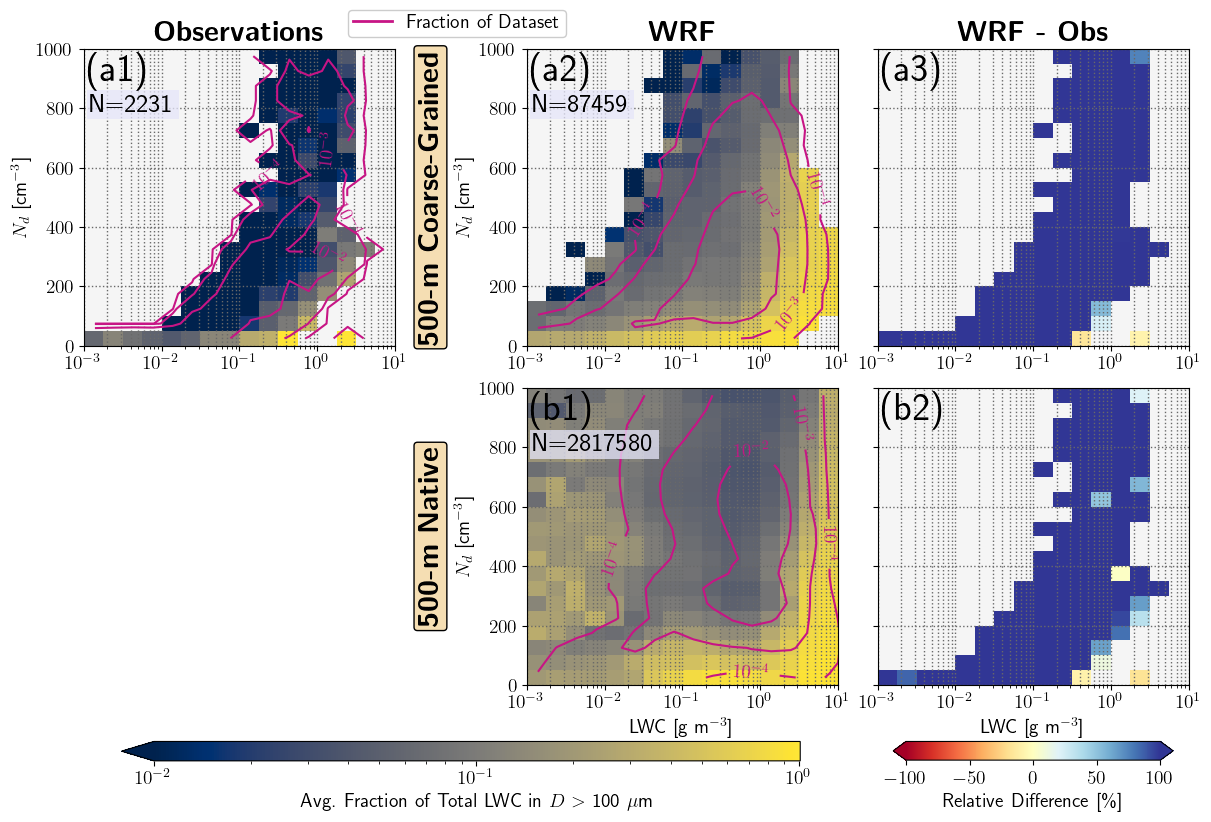

done


In [35]:
fig = plt.figure(figsize=(12, 8), constrained_layout=True) # Increased height slightly for colorbars
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)
ax6 = fig.add_subplot(236)
axlist = [ax1,ax2,ax3,ax4,ax5,ax6]
Fontsize=14
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.set_xlim(1.e-3,1.e1)
    ax.set_xscale('log')
    

ax1.set_title(r"\textbf{Observations}",fontsize=Fontsize*1.5)
ax2.set_title(r'\textbf{WRF}',fontsize=Fontsize*1.5)
ax3.set_title(r'\textbf{WRF - Obs}',fontsize=Fontsize*1.5)


for ax in axlist:
    ax.set_ylim(0,1000)
axlist_left = [ax1,ax2, ax5]
axlist_mid = []
axlist_right = [ax3,ax6]
axlist_bot = [ax4,ax5,ax6]
for ax in axlist_mid:
    ax.set_yticklabels([])
for ax in axlist_right:
    ax.set_yticklabels([])

for ax in axlist_left:
    ax.set_ylabel('$N_{d}$ [cm$^{-3}$]',fontsize=Fontsize)
for ax in axlist_bot:
    ax.set_xlabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    
    cmap = mpl.colormaps.get_cmap('cividis').copy()

vmin = 1.e-2
vmax = 1.
inc = 0.05
z_bins = np.arange(vmin,vmax+inc,inc) # um
# Custom formatter function to display labels in scientific notation
def fmt(x):
    return f'$10^{{{int(np.log10(x))}}}$'
    
c_color = 'mediumvioletred'
#c_color = 'tomato'
lab = 'Avg. Fraction of Total LWC in $D$ $>$ 100 $\\mu$m' # Removed newline for horizontal label
extend='min'
c_font = 14
dumy=0.85
#=============================================
# Obs - ax1 
#=============================================
ax=ax1
samp_size = len(obs_dict_updraft['total_conc'])
dum = obs_mean_linlog_updraft.copy() 
dum[dum < vmin] = vmin
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm1 = ax.pcolormesh(lwc_bins, conc_bins_lin, dum.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))
cm = ax.contour(lwc_midbins,conc_midbins_lin,obs_frac_linlog_updraft.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)


#=============================================
# WRF d3
#=============================================
ax=ax2
samp_size = len(d3_wrf_dict_updraft['N'])
# Use the same colormap and normalization
ax.pcolormesh(lwc_bins, conc_bins_lin, d3_wrf_mean_linlog_updraft.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))

cm = ax.contour(lwc_midbins,conc_midbins_lin,d3_wrf_frac_linlog_updraft.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)

#=============================================
# Obs - WRF d3
#=============================================
cmap_diff = mpl.colormaps.get_cmap('RdYlBu').copy()
ax = ax3
dum_obs = obs_mean_linlog_updraft.T.copy()
dum_obs[dum_obs == 0.] = 1.e-12
rel_diff = (d3_wrf_mean_linlog_updraft.T - dum_obs)/dum_obs*100.
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm3 = ax.pcolormesh(lwc_bins, conc_bins_lin, rel_diff, cmap=cmap_diff, shading='auto', vmin=-100, vmax=100)

#=============================================
# WRF d3 Native
#=============================================
ax=ax5
samp_size = len(d3_native_wrf_dict_updraft['N'])
# Use the same colormap and normalization
ax.pcolormesh(lwc_bins, conc_bins_lin, d3_native_wrf_mean_linlog_updraft.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=2))

cm = ax.contour(lwc_midbins,conc_midbins_lin,d3_native_wrf_frac_linlog_updraft.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)

#=============================================
# Obs - WRF d3 Native
#=============================================
cmap_diff = mpl.colormaps.get_cmap('RdYlBu').copy()
ax = ax6
dum_obs = obs_mean_linlog_updraft.T.copy()
dum_obs[dum_obs == 0.] = 1.e-12
rel_diff = (d3_native_wrf_mean_linlog_updraft.T - dum_obs)/dum_obs*100.
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm3 = ax.pcolormesh(lwc_bins, conc_bins_lin, rel_diff, cmap=cmap_diff, shading='auto', vmin=-100, vmax=100)

#=============================================
# ADD NEW HORIZONTAL COLORBARS AT THE BOTTOM
#=============================================

# Shared colorbar for the first two panels
cbar1 = fig.colorbar(pcm1, ax=[ax4, ax5], orientation='horizontal', location='bottom',
                     pad=0.01, extend=extend, shrink=0.9, aspect=35)
cbar1.ax.tick_params(labelsize=Fontsize)
cbar1.set_label(lab, fontsize=Fontsize) # Use set_label for horizontal colorbars

# Separate colorbar for the third panel
cbar3 = fig.colorbar(pcm3, ax=ax6, orientation='horizontal', location='bottom',
                     pad=0.01, extend='both', shrink=0.9, aspect=15)
cbar3.ax.tick_params(labelsize=Fontsize)
cbar3.set_label('Relative Difference [\\%]', fontsize=Fontsize)


labs = ['(a1)','(a2)','(a3)',\
        '(b1)','(b1)','(b2)']
for i,ax in enumerate(axlist):
    ax.text(0.01,0.99,labs[i],fontsize=Fontsize*2.,ha='left',va='top',transform=ax.transAxes)


#plt.suptitle('\\underline{\\textbf{Fraction of total LWC in $D$ $>$ 100 $\\mu$m}}', fontsize=Fontsize*1.5, color='navy')
back_color = 'whitesmoke'
for ax in axlist:
    ax.set_facecolor(back_color)
# Create a custom legend
custom_line = Line2D([0], [0], color=c_color, lw=2)
fig.legend([custom_line], ['Fraction of Dataset'],framealpha=True,bbox_to_anchor=(0.475,1.02),fontsize=Fontsize,bbox_transform=fig.transFigure,borderpad=0.25)

bbox = dict(facecolor='wheat', edgecolor='k', alpha=1,boxstyle='round', pad=0.125)
text1 = ax2.text(-0.31,0.5,r'\textbf{500-m Coarse-Grained}',fontsize=Fontsize*1.5,ha='center',va='center',transform=ax2.transAxes,rotation=90,bbox=bbox)
text2 = ax5.text(-0.31,0.5,r'\textbf{500-m Native}',fontsize=Fontsize*1.5,ha='center',va='center',transform=ax5.transAxes,rotation=90,bbox=bbox)
#text2.set_in_layout(False)
#fig.delaxes(ax4)
ax4.set_visible(False)

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
fig_name = f"fig_LWC_Nd_Frac_Joint_Histogram_LASSO_500m_native_updraft_only.png"
#plt.savefig(save_path + fig_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('done')